In [1]:
import notebook_dropdowns
notebook_dropdowns.helper()


HTML(value="\n    <p> <b style='color:black'> List of available commands for selecting geographic sites for an…

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
from dask.diagnostics import ProgressBar
import warnings
import gc
import datetime
from contextlib import redirect_stdout
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import netCDF4
import matplotlib as mpl
from PIL import Image
import folium
import io
import base64
from branca.colormap import linear

In [3]:
from datacube import Datacube
dc = Datacube()
dc.list_products()

,name,description,license,default_crs,default_resolution
name,,,,,
cmems_poc,cmems_poc,CMEMS L4 3D BGC monthly climatology of particu...,proprietary,EPSG:4326,"Resolution(x=0.25, y=-0.25)"
cmems_sss,cmems_sss,CMEMS L4 multi-sensor sea surface salinity on ...,proprietary,EPSG:4326,"Resolution(x=0.125, y=-0.125)"
s3_olci_chl,s3_olci_chl,Sentinel-3 OLCI Level-2 Water Full Resolution ...,proprietary,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_slstr_sst,s3_slstr_sst,Sentinel-3 SLSTR Level-2 sea surface temperatu...,proprietary,EPSG:4326,"Resolution(x=0.01, y=-0.01)"
sentinel_2_ard,sentinel_2_ard,Sentinel-2 Analysis Ready Data (ARD) from the ...,None,EPSG:27700,"Resolution(x=10, y=-10)"


In [4]:
# initialization of site selection #
date_select = notebook_dropdowns.date_selection()

HTML(value='<b style=\'color:#1a2172\'> Use the calendars below to set a start date and an end date for analys…

DatePicker(value=None, description='Start date', layout=Layout(width='40%'), step=1, style=DescriptionStyle(de…

DatePicker(value=None, description='End date', layout=Layout(width='40%'), step=1, style=DescriptionStyle(desc…

Button(description='Reset', style=ButtonStyle())

HTML(value="<b style='color:#1a2172'> Start date: </b> Not set <b style='color:#1a2172'> &nbsp; End date: </b>…

In [5]:
# fetch selected dates
start_date, end_date = notebook_dropdowns.date_selected()
start_date, end_date

('2021-05-01', '2021-08-31')

In [6]:
# initialization of site selection #
polygon_select = notebook_dropdowns.area_selection()

HTML(value="<b style='color:#1a2172'> Use the dropdown menu below to select areas or sites for analysis <p> Us…

Dropdown(description='Area Selection Type', layout=Layout(width='40%'), options=('1. DRAW AREA', '2. USER UPLO…

Dropdown(description='Filter dataset or select all', layout=Layout(width='40%'), options=('lysekil boundary', …

Dropdown(description='OPTIONAL - Select a site', layout=Layout(width='40%'), options=('Lysekil_Boundary',), st…

Button(description='Reset', style=ButtonStyle())

In [29]:
#  map to select or draw a site
notebook_dropdowns.map_and_select_area(polygon_select)

Generating Interactive Map ...


IntProgress(value=0)

HTML(value="<b style='color:#1a2172'> After drawing area of interest on the map, wait for 'Selected Area:' con…

In [8]:
#  visualize selected option (add loading bar)
notebook_dropdowns.visualize_selected_area()

HTML(value="<b style='color:#1a2172'> Check that area displayed is your area of interest before proceeding. If…

HTML(value="<b style='color:#1a2172'> Selected area: 42806.53 hectares </b><br>")

In [9]:
#  print selected area bbox
bbox = notebook_dropdowns.polygon_selected_tobbox()
bbox

(11.311563, 58.229949, 11.506553, 58.323101)

In [10]:
# # Load data for May - August 2021
min_lon, min_lat, max_lon, max_lat = bbox

# if area is large then use area chunks
# dask_chunks={
#     'time': -1,
#     'latitude': 80,
#     'longitude': 110,
# }

# small area selected 
# SSS:   2 x 2
# SST:   7 x 15
# CHL:   20 x 47
dask_chunks={'time': -1}



# Define time range
time_range = (start_date, end_date)

# Load CMEMS POC at depth 0
cmems_poc = dc.load(
    product='cmems_poc',
    measurements='poc_depth_0',
    lon=(min_lon, max_lon),
    lat=(min_lat, max_lat),
    time=time_range,
    dask_chunks=dask_chunks
)

# Load CMEMS SSS (Sea Surface Salinity)
cmems_sss = dc.load(
    product='cmems_sss',
    lon=(min_lon, max_lon),
    lat=(min_lat, max_lat),
    time=time_range,
    dask_chunks=dask_chunks
)

# Load S3 SLSTR SST (Sea Surface Temperature)
s3_slstr_sst = dc.load(
    product='s3_slstr_sst',
    lon=(min_lon, max_lon),
    lat=(min_lat, max_lat),
    time=time_range,
     dask_chunks=dask_chunks
)

# Load S3 OLCI Chlorophyll
s3_olci_chl = dc.load(
    product='s3_olci_chl',
    lon=(min_lon, max_lon),
    lat=(min_lat, max_lat),
    time=time_range, 
    dask_chunks=dask_chunks
)

# Display loaded datasets
print("CMEMS POC:")
print(cmems_poc)
print("\nCMEMS SSS:")
print(cmems_sss)
print("\nS3 SLSTR SST:")
print(s3_slstr_sst)
print("\nS3 OLCI Chlorophyll:")
print(s3_olci_chl)


Querying product Product(name='cmems_poc', id_=12)
Querying product Product(name='cmems_sss', id_=13)
Querying product Product(name='s3_slstr_sst', id_=16)
Querying product Product(name='s3_olci_chl', id_=15)


CMEMS POC:
<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*

CMEMS SSS:
<xarray.Dataset> Size: 7kB
Dimensions:      (time: 123, latitude: 2, longitude: 3)
Coordinates:
  * time         (time) datetime64[ns] 984B 2021-05-01 2021-05-02 ... 2021-08-31
  * latitude     (latitude) float64 16B 58.31 58.19
  * longitude    (longitude) float64 24B 11.31 11.44 11.56
    spatial_ref  int32 4B 4326
Data variables:
    sos          (time, latitude, longitude) float32 3kB dask.array<chunksize=(123, 2, 3), meta=np.ndarray>
    sos_error    (time, latitude, longitude) float32 3kB dask.array<chunksize=(123, 2, 3), meta=np.ndarray>
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

S3 SLSTR SST:
<xarray.Dataset> Size: 940kB
Dimensions:                  (time: 1163, latitude: 10, longitude: 20)
Coordinates:
  * time                     (time) datetime64[ns] 9kB 2021-06-15T18:06:49 .....
  * latitude                 (latitude) float64 80B 58.33 58.32 ... 58.25 5

In [11]:
# ============================================================
# COORDINATE ALIGNMENT SETUP
# ============================================================
# Different CMEMS products can use slightly different lat/lon
# grids. We designate the CHL dataset as the master reference cos it has the use the highest resolution grid
# and will interpolate all other variables onto it.

# Align coordinates - using CHL data as reference
# Grid alignment using ds_poc as the reference grid and interpolating all other variables to it, 
# as a way to handle mismatched grids.

reference_ds = s3_olci_chl

ref_lats = reference_ds.latitude
ref_lons = reference_ds.longitude
print(f"Aligning coordinates to s3_olci_chl ref_latitude and ref_longitude ...")

Aligning coordinates to s3_olci_chl ref_latitude and ref_longitude ...


In [12]:
# ============================================================
# INTERPOLATE ALL VARIABLES TO A COMMON DAILY GRID
# ============================================================
# Some products are weekly (POC) or have slightly shifted grids.
# xarray .interp() fills gaps via linear interpolation in time
# and bilinear interpolation in space.
# fill_value='extrapolate' avoids NaN edges at domain borders.

# Result: ds_daily is a single lazy Dataset with 4 variables on
# a unified (time, latitude, longitude) grid ready for the model.
time_horizon     = pd.date_range(start=start_date, end=end_date, freq='D')
time_horizon_len = len(time_horizon)
print(f"Analysis period: {time_horizon[0].date()} → {time_horizon[-1].date()}  ({time_horizon_len} days)")
time_horizon_len
interp_kwargs = {'fill_value': 'extrapolate'}


Analysis period: 2021-05-01 → 2021-08-31  (123 days)


In [13]:
# poc_daily = (
#     cmems_poc["poc_depth_0"]
#     .interp(
#         time=time_horizon,
#         latitude=ref_lats,
#         longitude=ref_lons,
#         kwargs=interp_kwargs
#     )
# )

# sal_daily = (
#     cmems_sss["sos"]
#     .interp(
#         time=time_horizon,
#         latitude=ref_lats,
#         longitude=ref_lons,
#         kwargs=interp_kwargs
#     )
# )

# temp_daily = (
#     s3_slstr_sst["sea_surface_temperature"]
#     .interp(
#         time=time_horizon,
#         latitude=ref_lats,
#         longitude=ref_lons,
#         kwargs=interp_kwargs
#     )
# )

# chl_daily = (
#     s3_olci_chl["CHL_NN"] #or  s3_olci_chl["CHL_OC4ME"]
#     .interp(
#         time=time_horizon,
#         latitude=ref_lats,
#         longitude=ref_lons,
#         kwargs=interp_kwargs
#     )
# )

In [14]:
# ds_daily = xr.Dataset(
#     {
#         # "POC": poc_daily,
#         # 'POM': pom_daily,
#         # 'TPM': tpm_daily,
#         "salinity": sal_daily,
#         "temperature": temp_daily,
#         "Chl": chl_daily,
#     }
# )

# print("Merged daily dataset")
# ds_daily

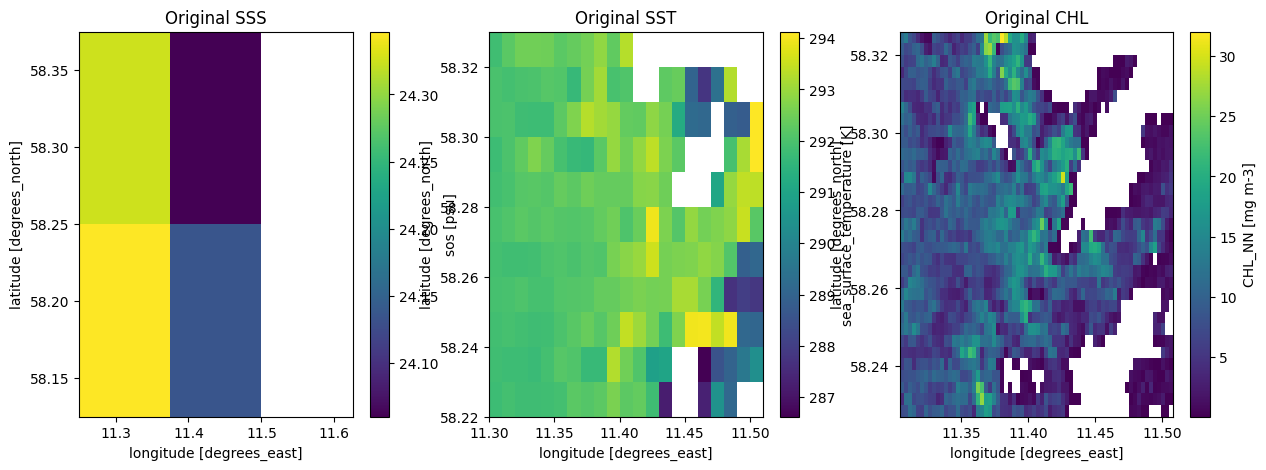

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

cmems_sss.sos.mean("time").plot(ax=ax[0])
ax[0].set_title("Original SSS")

s3_slstr_sst.sea_surface_temperature.mean("time").plot(ax=ax[1])
ax[1].set_title("Original SST")

s3_olci_chl.CHL_NN.mean("time").plot(ax=ax[2])
ax[2].set_title("Original CHL")

plt.show()

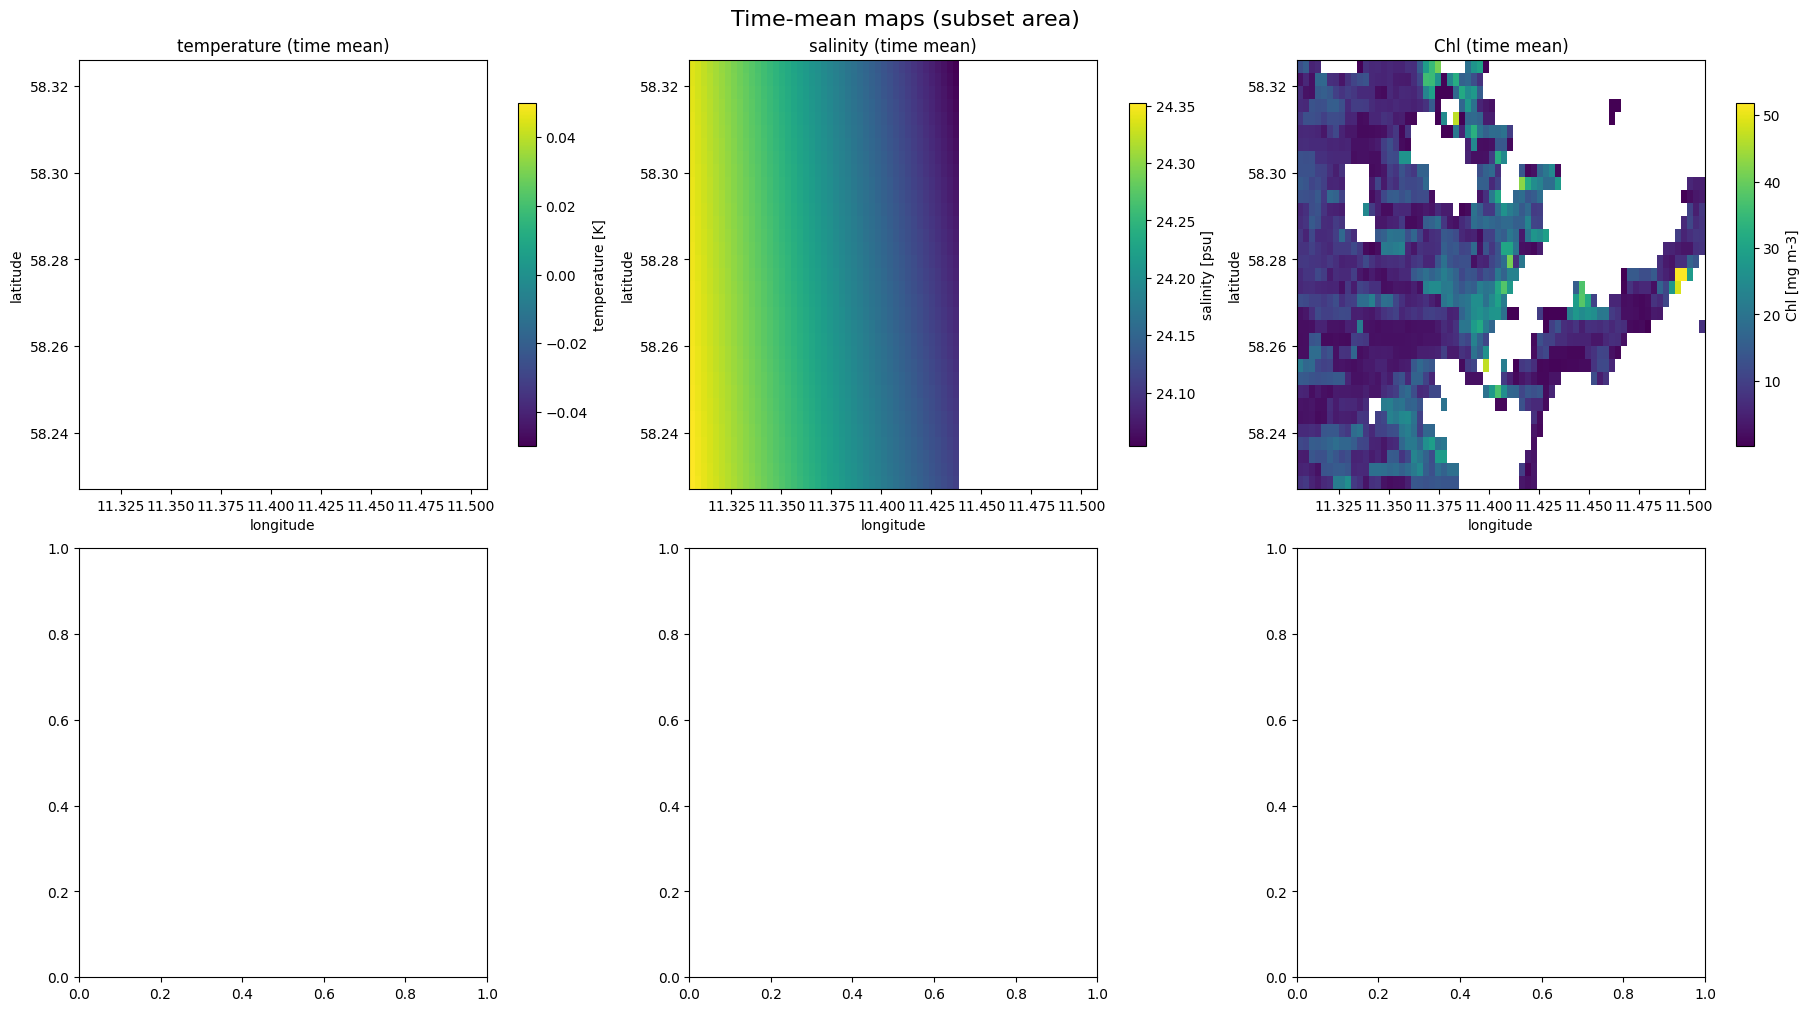

In [16]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Best practice: inspect inputs before running the model.
# This cell produces:
#   1. Six spatial time-mean maps showing geographic patterns
#   2. Temperature/salinity and food-variable time series at
#      the central pixel to check temporal variability.
# If a variable looks flat/random it came from fake-data fallback and model results for it will not be physical.


# Quick guard
if ds_daily is None or len(ds_daily.coords.get('time', [])) == 0:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    # Plot spatial time-mean maps for key variables
    # vars_to_map = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
    vars_to_map = ['temperature', 'salinity', 'Chl']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    for ax, var in zip(axes, vars_to_map):
        if var in ds_daily:
            try:
                da_mean = ds_daily[var].mean(dim='time')
                im = da_mean.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'shrink': 0.8})
                ax.set_title(f"{var} (time mean)")
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
            except Exception as e:
                ax.text(0.5, 0.5, f"Plot failed: {e}", ha='center')
        else:
            ax.text(0.5, 0.5, f"{var} not found", ha='center')

    plt.suptitle("Time-mean maps (subset area)", fontsize=16)
    # plt.savefig("ds_daily_time_mean_maps.png", dpi=150)
    plt.show()


In [15]:

def plot_mean_timeseries(dataset, variable_name, ylabel, title, color='steelblue', 
                         kelvin_to_celsius=False, figsize=(14, 6)):
    """
    Calculate spatial mean and plot time series for any dataset variable.
    
    Parameters:
    -----------
    dataset : xarray.Dataset or xarray.DataArray
        Input dataset containing the variable to plot
    variable_name : str
        Name of the variable to analyze (if dataset is xarray.Dataset)
        If dataset is already a DataArray, this parameter is used only for reference
    ylabel : str
        Label for y-axis (e.g., 'Mean SST (°C)', 'Mean Chlorophyll (mg/m³)')
    title : str
        Title for the plot
    color : str, optional
        Color for the line plot (default: 'steelblue')
    kelvin_to_celsius : bool, optional
        If True, convert values from Kelvin to Celsius (default: False)
    figsize : tuple, optional
        Figure size (default: (14, 6))
    
    Returns:
    --------
    mean_values : xarray.DataArray
        Spatially averaged time series
    """
    # Extract the variable if dataset is provided
    if hasattr(dataset, 'variables') and variable_name in dataset.variables:
        data = dataset[variable_name]
    else:
        data = dataset
    
    # Convert from Kelvin to Celsius if needed
    if kelvin_to_celsius:
        data = data - 273.15
    
    # Calculate mean values over space for each time step
    # Identify spatial dimensions (typically latitude/longitude or y/x)
    spatial_dims = [dim for dim in data.dims if dim in ['latitude', 'longitude', 'lat', 'lon', 'x', 'y']]
    
    if spatial_dims:
        mean_values = data.mean(dim=spatial_dims)
    else:
        mean_values = data
    
    # Create the time series plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot the time series
    mean_values.plot(ax=ax, linewidth=2, marker='o', markersize=4, color=color)
    
    # Customize the plot
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{ylabel} Statistics:")
    print(f"  Overall mean: {mean_values.mean().values:.2f}")
    print(f"  Minimum: {mean_values.min().values:.2f}")
    print(f"  Maximum: {mean_values.max().values:.2f}")
    print(f"  Standard deviation: {mean_values.std().values:.2f}")
    
    return mean_values

    


In [16]:
def clean_and_interpolate_timeseries(dataset, variable_name=None, 
                                    ylabel='Mean Value', 
                                    title_prefix='Variable',
                                    color='steelblue',
                                    figsize=(16, 7),
                                    print_table=True):
    """
    Clean, resample, and interpolate time series data from xarray dataset.
    
    Parameters:
    -----------
    dataset : xarray.Dataset or xarray.DataArray
        Input dataset containing the variable to process
    variable_name : str, optional
        Name of the variable to analyze (if dataset is xarray.Dataset)
        If None and dataset is a DataArray, uses the DataArray directly
    ylabel : str, optional
        Label for y-axis (default: 'Mean Value')
    title_prefix : str, optional
        Prefix for plot title (default: 'Variable')
    color : str, optional
        Color for the original data points (default: 'steelblue')
    figsize : tuple, optional
        Figure size (default: (16, 7))
    print_table : bool, optional
        Whether to print the data table (default: True)
    
    Returns:
    --------
    dict containing:
        - 'daily_mean': pandas Series with daily mean values (before interpolation)
        - 'complete': pandas Series with interpolated values
        - 'dataframe': pandas DataFrame with temperature, is_original, and source columns
        - 'original_data': pandas DataFrame with only original measurements
        - 'interpolated_data': pandas DataFrame with only interpolated values
    """
    
    # Extract the variable if dataset is provided
    if hasattr(dataset, 'variables') and variable_name and variable_name in dataset.variables:
        data = dataset[variable_name]
    else:
        data = dataset
    
    # Drop NaN values first
    data_clean = data.dropna(dim='time')
    
    # Convert to pandas Series for easier date handling
    series = data_clean.to_series()
    
    # Resample to daily frequency and compute mean
    daily_mean = series.resample('D').mean()
    
    # Drop any NaN values that might result from days with no data
    daily_mean = daily_mean.dropna()
    
    # Print original daily means if requested
    if print_table:
        print("="*50)
        print(f"Daily Mean {title_prefix} Values")
        print("="*50)
        print(f"{'Date':<20} {ylabel:>15}")
        print("-"*50)
        
        for date, value in daily_mean.items():
            date_str = str(date)[:10]
            print(f"{date_str:<20} {value:>15.2f}")
        
        print("="*50)
        print(f"\nTotal number of days with data: {len(daily_mean)}")
    
    # Create a complete date range from the first to last date
    date_range = pd.date_range(start=daily_mean.index.min(), 
                               end=daily_mean.index.max(), 
                               freq='D')
    
    # Reindex to include all dates
    complete = daily_mean.reindex(date_range)
    
    # Create a flag to mark original vs interpolated values (before interpolation)
    is_original = ~complete.isna()
    
    # Perform linear interpolation for missing values
    interpolated = complete.interpolate(method='linear')
    
    # Create a DataFrame with both values and flags
    df = pd.DataFrame({
        'value': interpolated,
        'is_original': is_original,
        'source': ['Original' if orig else 'Interpolated' for orig in is_original]
    })
    
    # Display the complete table if requested
    if print_table:
        print("\n" + "="*70)
        print(f"Complete {title_prefix} Time Series")
        print("(With Interpolated Values)")
        print("="*70)
        print(f"{'Date':<20} {ylabel:<15} {'Source':<20}")
        print("-"*70)
        
        for date, row in df.iterrows():
            date_str = str(date)[:10]
            value = row['value']
            source = row['source']
            
            # Use different formatting for interpolated values
            if source == 'Interpolated':
                print(f"{date_str:<20} {value:>10.2f}      {source:<20} *")
            else:
                print(f"{date_str:<20} {value:>10.2f}      {source:<20}")
        
        print("="*70)
        print(f"\nTotal days: {len(df)}")
        print(f"Original values: {is_original.sum()}")
        print(f"Interpolated values: {(~is_original).sum()}")
        print("\n* Interpolated values are marked with an asterisk")
    
    # Create a visualization showing original vs interpolated values
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot interpolated values as a continuous line
    ax.plot(df.index, df['value'], 
            linewidth=1.5, color='lightblue', alpha=0.7, 
            label='Complete time series (with interpolation)', zorder=1)
    
    # Overlay original values with larger markers
    original_data = df[df['is_original']]
    ax.scatter(original_data.index, original_data['value'], 
              s=80, color=color, marker='o', 
              label='Original measurements', zorder=3, 
              edgecolors='darkblue' if color == 'steelblue' else 'black', 
              linewidth=1)
    
    # Highlight interpolated values with different markers
    interpolated_data = df[~df['is_original']]
    ax.scatter(interpolated_data.index, interpolated_data['value'], 
              s=60, color='orange', marker='x', 
              label='Interpolated values', zorder=2, linewidth=2)
    
    # Customize the plot
    ax.set_title(f'{title_prefix} Time Series - Original vs Interpolated Values', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Overall mean: {df['value'].mean():.2f}")
    print(f"  Minimum: {df['value'].min():.2f}")
    print(f"  Maximum: {df['value'].max():.2f}")
    print(f"  Standard deviation: {df['value'].std():.2f}")
    print(f"\n  Original data mean: {original_data['value'].mean():.2f}")
    print(f"  Interpolated data mean: {interpolated_data['value'].mean():.2f}")
    
    # Return multiple outputs for later use
    return {
        'daily_mean': daily_mean,
        'complete': df['value'],
        'dataframe': df,
        'original_data': original_data,
        'interpolated_data': interpolated_data
    }

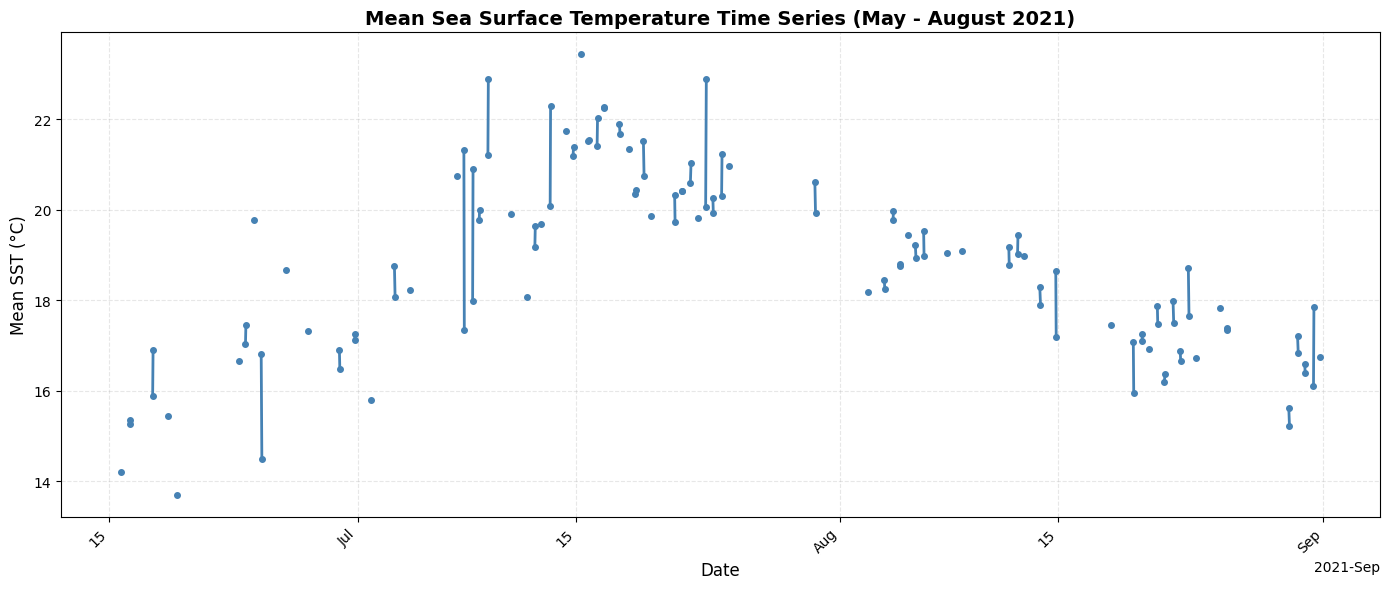


Mean SST (°C) Statistics:
  Overall mean: 18.77
  Minimum: 13.70
  Maximum: 23.43
  Standard deviation: 2.06


In [17]:
# Use the function for Sea Surface Temperature
mean_sst = plot_mean_timeseries(
    dataset=s3_slstr_sst,
    variable_name='sea_surface_temperature',
    ylabel='Mean SST (°C)',
    title='Mean Sea Surface Temperature Time Series (May - August 2021)',
    color='steelblue',
    kelvin_to_celsius=True
)

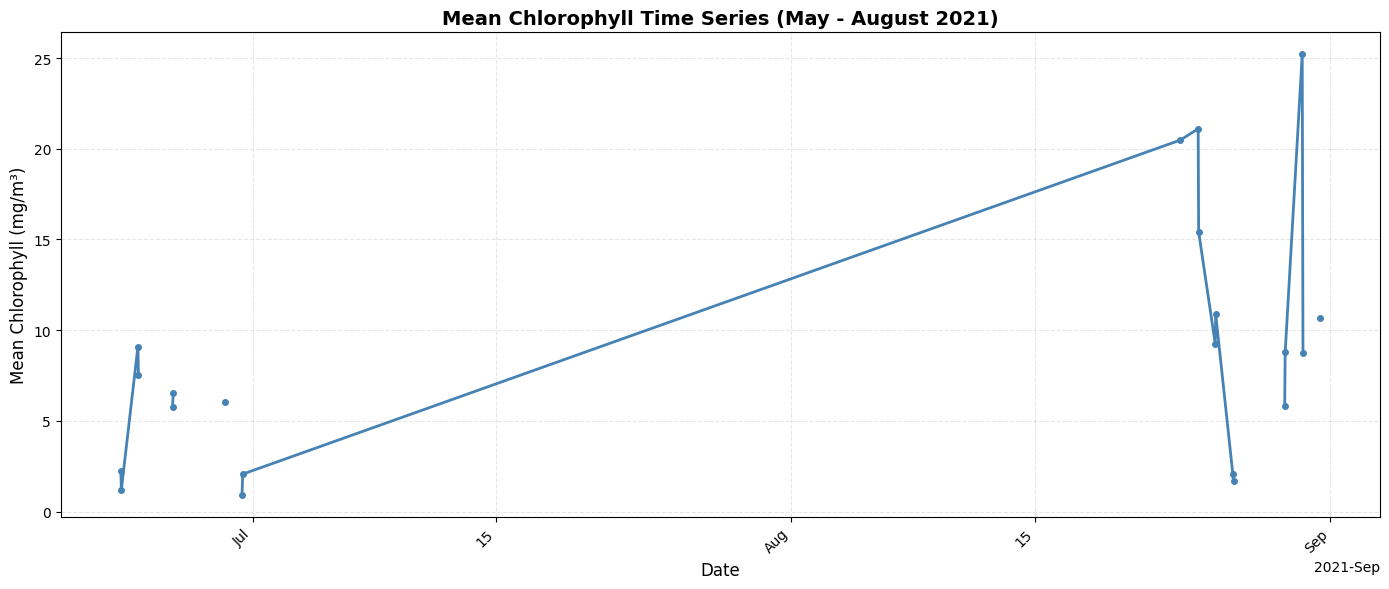


Mean Chlorophyll (mg/m³) Statistics:
  Overall mean: 8.64
  Minimum: 0.94
  Maximum: 25.20
  Standard deviation: 6.71


In [18]:
# Use the function for Chlorophyll
mean_chl = plot_mean_timeseries(
    dataset=s3_olci_chl,
    variable_name='CHL_OC4ME',
    ylabel='Mean Chlorophyll (mg/m³)',
    title='Mean Chlorophyll Time Series (May - August 2021)',
    color='steelblue'
)

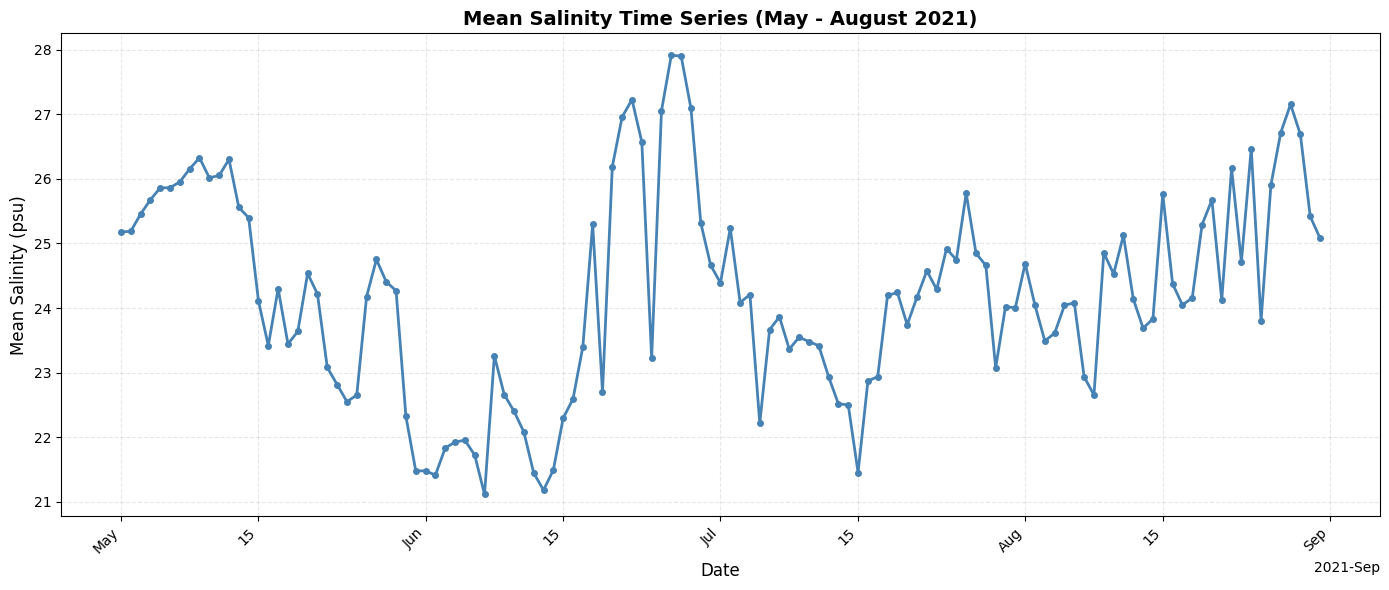


Mean Salinity (psu) Statistics:
  Overall mean: 24.22
  Minimum: 21.11
  Maximum: 27.91
  Standard deviation: 1.57


In [19]:
# Use the function for Salinity
mean_sos = plot_mean_timeseries(
    dataset=cmems_sss,
    variable_name='sos',
    ylabel='Mean Salinity (psu)',
    title='Mean Salinity Time Series (May - August 2021)',
    color='steelblue'
)

Daily Mean Sea Surface Temperature Values
Date                   Mean SST (°C)
--------------------------------------------------
2021-06-15                     14.21
2021-06-16                     15.30
2021-06-17                     16.39
2021-06-18                     15.44
2021-06-19                     13.70
2021-06-23                     17.05
2021-06-24                     17.03
2021-06-26                     18.67
2021-06-27                     17.33
2021-06-29                     16.69
2021-06-30                     17.18
2021-07-01                     15.80
2021-07-03                     18.42
2021-07-04                     18.22
2021-07-07                     19.80
2021-07-08                     19.66
2021-07-09                     22.05
2021-07-10                     19.91
2021-07-11                     18.07
2021-07-12                     19.51
2021-07-13                     21.18
2021-07-14                     21.43
2021-07-15                     22.16
2021-07-16         

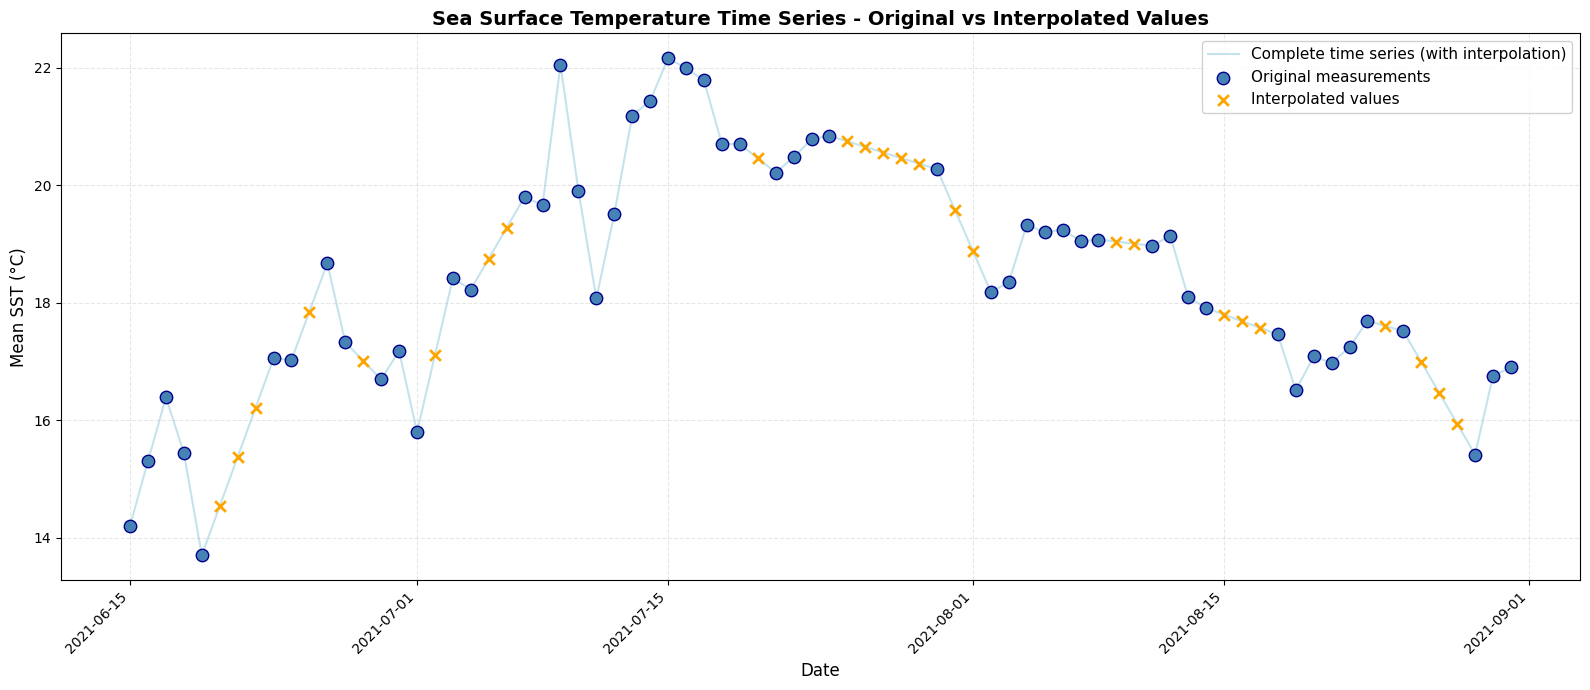


Summary Statistics:
  Overall mean: 18.40
  Minimum: 13.70
  Maximum: 22.16
  Standard deviation: 1.95

  Original data mean: 18.47
  Interpolated data mean: 18.23


In [20]:
### Interpolated Sea Surface Temperature
# Use the function for Sea Surface Temperature
sst_results = clean_and_interpolate_timeseries(
    dataset=mean_sst,
    variable_name=None,  # mean_sst is already a DataArray
    ylabel='Mean SST (°C)',
    title_prefix='Sea Surface Temperature',
    color='steelblue'
)

# Store the results for later use
daily_mean_sst = sst_results['daily_mean']
mean_sst_complete = sst_results['complete']

Daily Mean Chlorophyll Concentration Values
Date                 Mean Chlorophyll Concentration (mg/m^3)
--------------------------------------------------
2021-06-23                      1.71
2021-06-24                      8.32
2021-06-26                      6.15
2021-06-29                      6.05
2021-06-30                      1.50
2021-08-23                     20.48
2021-08-24                     18.26
2021-08-25                     10.07
2021-08-26                      1.89
2021-08-29                      7.29
2021-08-30                     16.98
2021-08-31                     10.67

Total number of days with data: 12

Complete Chlorophyll Concentration Time Series
(With Interpolated Values)
Date                 Mean Chlorophyll Concentration (mg/m^3) Source              
----------------------------------------------------------------------
2021-06-23                 1.71      Original            
2021-06-24                 8.32      Original            
2021-06-25          

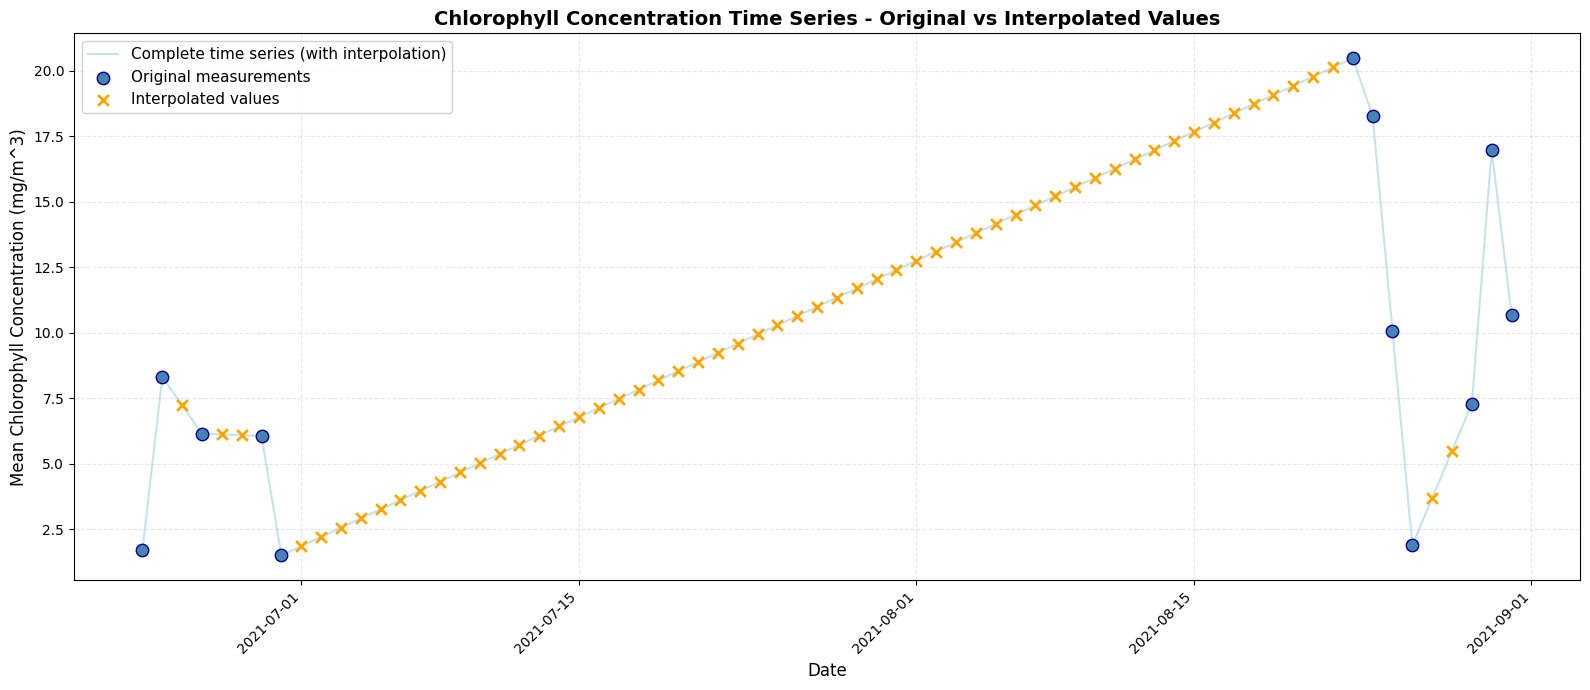


Summary Statistics:
  Overall mean: 10.29
  Minimum: 1.50
  Maximum: 20.48
  Standard deviation: 5.58

  Original data mean: 9.11
  Interpolated data mean: 10.54


In [21]:
# Use the function for Chlorophyll Concentration
chl_results = clean_and_interpolate_timeseries(
    dataset=mean_chl,
    variable_name=None,  # mean_sst is already a DataArray
    ylabel='Mean Chlorophyll Concentration (mg/m^3)',
    title_prefix='Chlorophyll Concentration',
    color='steelblue'
)

# Store the results for later use
daily_mean_chl = chl_results['daily_mean']
mean_chl_complete = chl_results['complete']

Daily Mean Sea Surface Salinity Values
Date                 Mean Salinity (psu)
--------------------------------------------------
2021-05-01                     25.18
2021-05-02                     25.19
2021-05-03                     25.45
2021-05-04                     25.68
2021-05-05                     25.86
2021-05-06                     25.86
2021-05-07                     25.95
2021-05-08                     26.15
2021-05-09                     26.33
2021-05-10                     26.02
2021-05-11                     26.05
2021-05-12                     26.30
2021-05-13                     25.56
2021-05-14                     25.40
2021-05-15                     24.11
2021-05-16                     23.42
2021-05-17                     24.30
2021-05-18                     23.44
2021-05-19                     23.64
2021-05-20                     24.54
2021-05-21                     24.22
2021-05-22                     23.08
2021-05-23                     22.82
2021-05-24        

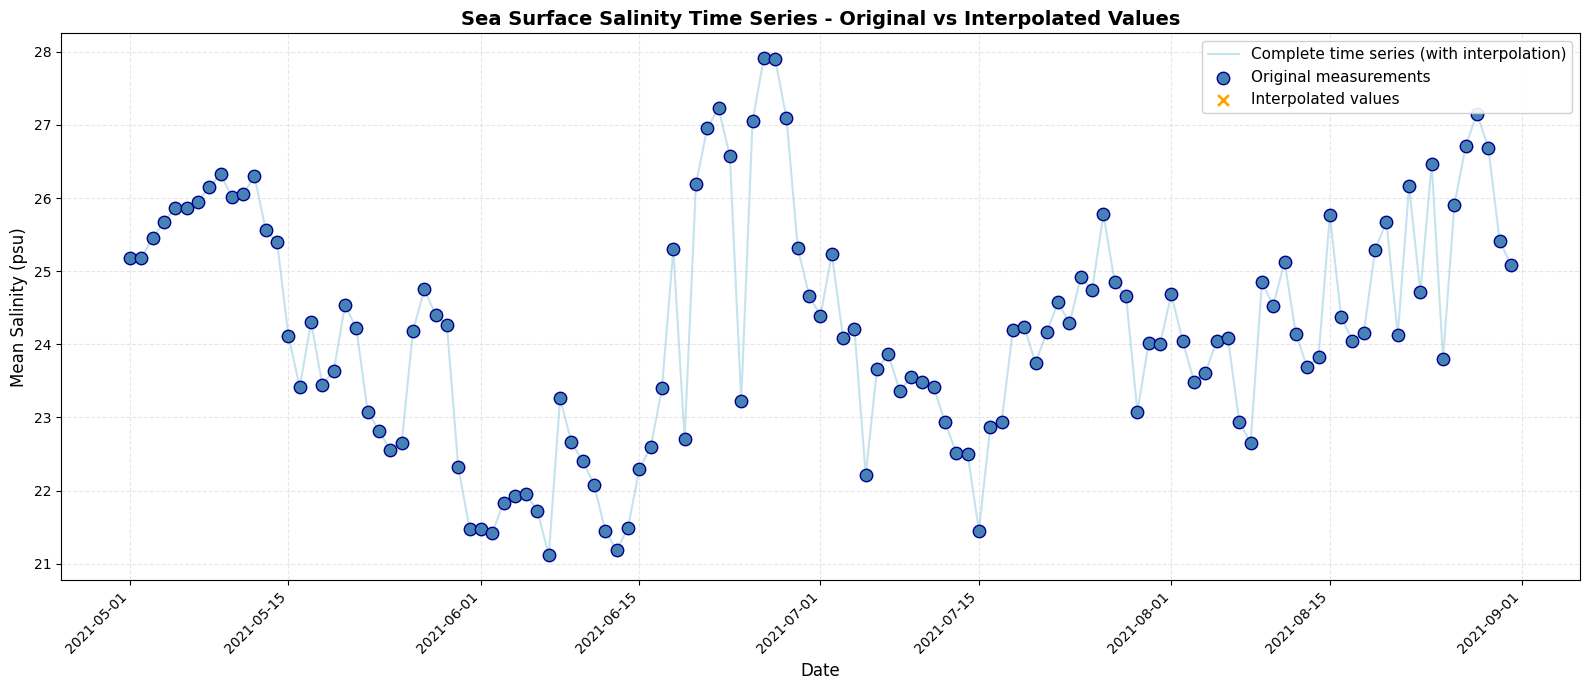


Summary Statistics:
  Overall mean: 24.22
  Minimum: 21.11
  Maximum: 27.91
  Standard deviation: 1.58

  Original data mean: 24.22
  Interpolated data mean: nan


In [22]:
# Use the function for Sea Surface Salinity
sos_results = clean_and_interpolate_timeseries(
    dataset=mean_sos,
    variable_name=None,
    ylabel='Mean Salinity (psu)',
    title_prefix='Sea Surface Salinity',
    color='steelblue'
)

# Store the results for later use
daily_mean_sos = sos_results['daily_mean']
mean_sos_complete = sos_results['complete']

## Build a proper gridded, gap-filled combined dataset

The merge below used to collapse to a generic `dim_0` axis. That happened because
`mean_sos_complete`, `mean_sst_complete` and `mean_chl_complete` are **1‑D spatial‑mean**
pandas Series (latitude/longitude were already averaged away, and their index is not named
`time`). Merging them therefore loses the grid.

To keep a real `(time, latitude, longitude)` cube we instead:

1. Put every variable on the **same reference grid** (the CHL grid: `ref_lats` × `ref_lons`).
2. Aggregate sub‑daily / irregular satellite scenes to **one value per day**.
3. Interpolate in **time** onto the full daily horizon (`time_horizon`).
4. **Fill the gaps** (cloudy days, and dates with no scene at all) with the cleaned
   spatial‑mean series computed above — *fill missing with means*. Anything still empty
   falls back to the overall variable mean, so the final cube has **no NaNs**.

In [23]:
# ============================================================
# BUILD A PROPER GRIDDED, GAP-FILLED COMBINED DATASET
# ============================================================
# Keeps (time, latitude, longitude). Uses the cleaned spatial-mean
# series (mean_*_complete) only to fill days/pixels that have no data.
# Land / persistently-empty pixels are kept as NaN (white on maps),
# just like the original products.

def to_reference_grid(da, kelvin_to_celsius=False, extrapolate=False):
    """Put a (time, lat, lon) DataArray on the CHL reference grid + daily horizon."""
    # 1) collapse sub-daily / irregular scenes to one daily value per pixel
    da = da.resample(time='1D').mean()
    if kelvin_to_celsius:
        da = da - 273.15
    # 2) bilinear onto the reference lat/lon grid.
    #    extrapolate=False keeps NaN outside the data footprint (so land stays NaN)
    kwargs = {'fill_value': 'extrapolate'} if extrapolate else {}
    da = da.interp(latitude=ref_lats, longitude=ref_lons, kwargs=kwargs)
    # 3) onto the full daily horizon; days outside the data range stay NaN (filled below)
    da = da.interp(time=time_horizon)
    return da

def series_to_horizon(series):
    """Cleaned pandas mean-series -> 1-D xarray aligned to the full daily horizon (no NaN)."""
    da = xr.DataArray(np.asarray(series.values, dtype='float32'),
                      coords={'time': pd.DatetimeIndex(series.index)}, dims='time')
    da = da.reindex(time=time_horizon)
    da = da.interpolate_na('time')          # fill internal gaps (scipy linear, no bottleneck)
    return da.fillna(da.mean())             # leading/trailing edges -> series mean

def gridded_filled(raw_da, mean_series, kelvin_to_celsius=False,
                   mask_land=True, extrapolate=False):
    grid  = to_reference_grid(raw_da, kelvin_to_celsius=kelvin_to_celsius, extrapolate=extrapolate)
    # sea mask = pixels that have at least one real observation over the whole period.
    # land / always-empty pixels are False -> restored to NaN at the end.
    valid = grid.notnull().any('time')
    fill  = series_to_horizon(mean_series)        # 1-D (time,) fallback, broadcast over lat/lon
    grid  = grid.fillna(fill)                      # fill missing DAYS on observed (sea) pixels
    grid  = grid.fillna(float(grid.mean()))        # any sea pixel still empty -> overall mean
    if mask_land:
        grid = grid.where(valid)                   # put land/cloud-only pixels back to NaN (white)
    return grid.astype('float32')

# NOTE: temperature is converted Kelvin -> degC so it matches mean_sst_complete.
# Salinity stays unmasked + extrapolated: its native 2x3 grid is too coarse for a land mask.
salinity_grid    = gridded_filled(cmems_sss["sos"],                        mean_sos_complete,
                                   mask_land=False, extrapolate=True)
temperature_grid = gridded_filled(s3_slstr_sst["sea_surface_temperature"], mean_sst_complete,
                                   kelvin_to_celsius=True, mask_land=True)
chl_grid         = gridded_filled(s3_olci_chl["CHL_NN"],                    mean_chl_complete,
                                   mask_land=True)

ds_daily = xr.Dataset(
    {
        # "POC": poc_grid,
        # "POM": pom_grid,
        # "TPM": tpm_grid,
        "salinity":    salinity_grid,
        "temperature": temperature_grid,
        "Chl":         chl_grid,
    }
).compute()   # materialise the lazy dask arrays

ds_daily["salinity"].attrs    = {"units": "psu",    "long_name": "Sea surface salinity"}
ds_daily["temperature"].attrs = {"units": "degC",   "long_name": "Sea surface temperature"}
ds_daily["Chl"].attrs         = {"units": "mg m-3", "long_name": "Chlorophyll concentration"}

print("Merged daily dataset (gridded, temporal gaps filled, land kept as NaN)")
print("  NaNs per variable (land/empty pixels x days):",
      {v: int(ds_daily[v].isnull().sum()) for v in ds_daily.data_vars})
ds_daily

Merged daily dataset (gridded, temporal gaps filled, land kept as NaN)
  NaNs per variable (land/empty pixels x days): {'salinity': 0, 'temperature': 138252, 'Chl': 105657}


<xarray.Dataset> Size: 6MB
Dimensions:      (latitude: 33, longitude: 66, time: 123)
Coordinates:
  * latitude     (latitude) float64 264B 58.32 58.32 58.32 ... 58.23 58.23 58.23
  * longitude    (longitude) float64 528B 11.31 11.31 11.32 ... 11.5 11.5 11.51
  * time         (time) datetime64[ns] 984B 2021-05-01 2021-05-02 ... 2021-08-31
    spatial_ref  int32 4B 4326
Data variables:
    salinity     (time, latitude, longitude) float64 2MB 25.34 25.34 ... 25.08
    temperature  (time, latitude, longitude) float64 2MB nan nan ... nan nan
    Chl          (time, latitude, longitude) float64 2MB 10.29 10.29 ... nan nan

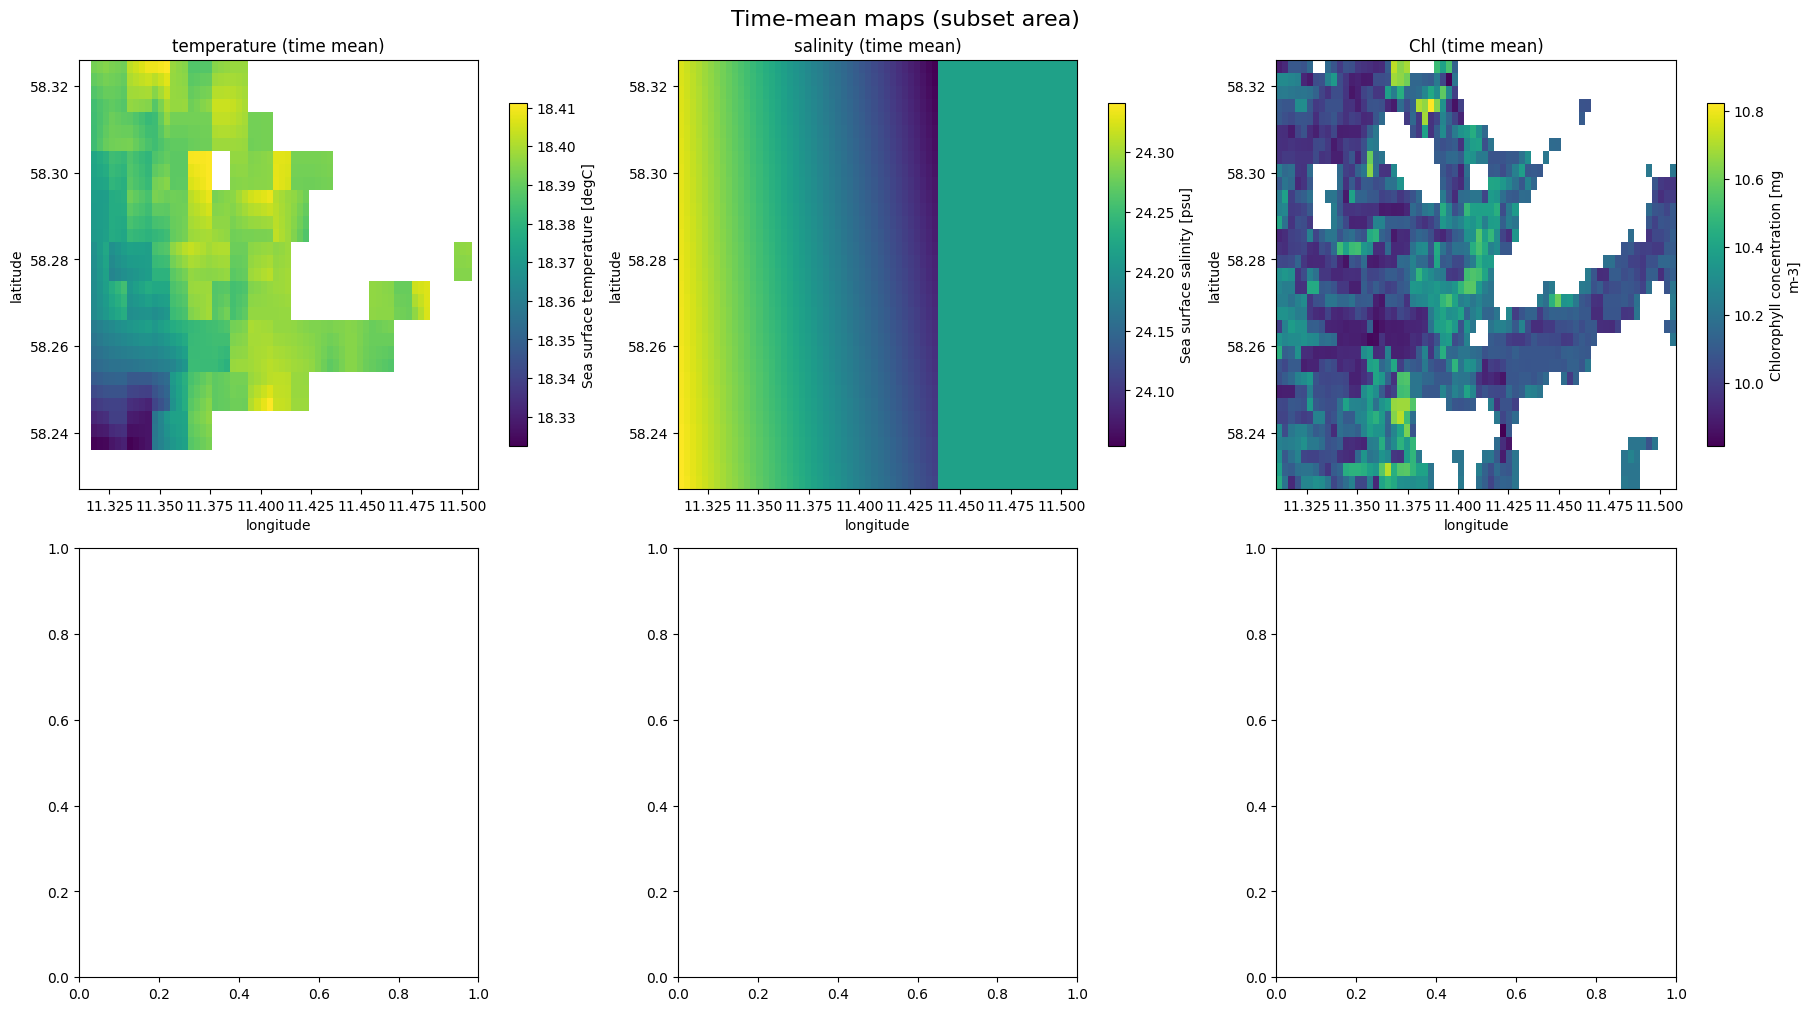

In [24]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Best practice: inspect inputs before running the model.
# This cell produces:
#   1. Six spatial time-mean maps showing geographic patterns
#   2. Temperature/salinity and food-variable time series at
#      the central pixel to check temporal variability.
# If a variable looks flat/random it came from fake-data fallback and model results for it will not be physical.


# Quick guard
if ds_daily is None or len(ds_daily.coords.get('time', [])) == 0:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    # Plot spatial time-mean maps for key variables
    # vars_to_map = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
    vars_to_map = ['temperature', 'salinity', 'Chl']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    for ax, var in zip(axes, vars_to_map):
        if var in ds_daily:
            try:
                da_mean = ds_daily[var].mean(dim='time')
                im = da_mean.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'shrink': 0.8})
                ax.set_title(f"{var} (time mean)")
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
            except Exception as e:
                ax.text(0.5, 0.5, f"Plot failed: {e}", ha='center')
        else:
            ax.text(0.5, 0.5, f"{var} not found", ha='center')

    plt.suptitle("Time-mean maps (subset area)", fontsize=16)
    # plt.savefig("ds_daily_time_mean_maps.png", dpi=150)
    plt.show()


In [26]:
#  visualize selected option (add loading bar)
notebook_dropdowns.visualize_selected_area()

HTML(value="<b style='color:#1a2172'> Check that area displayed is your area of interest before proceeding. If…

HTML(value="<b style='color:#1a2172'> Selected area: 42806.53 hectares </b><br>")

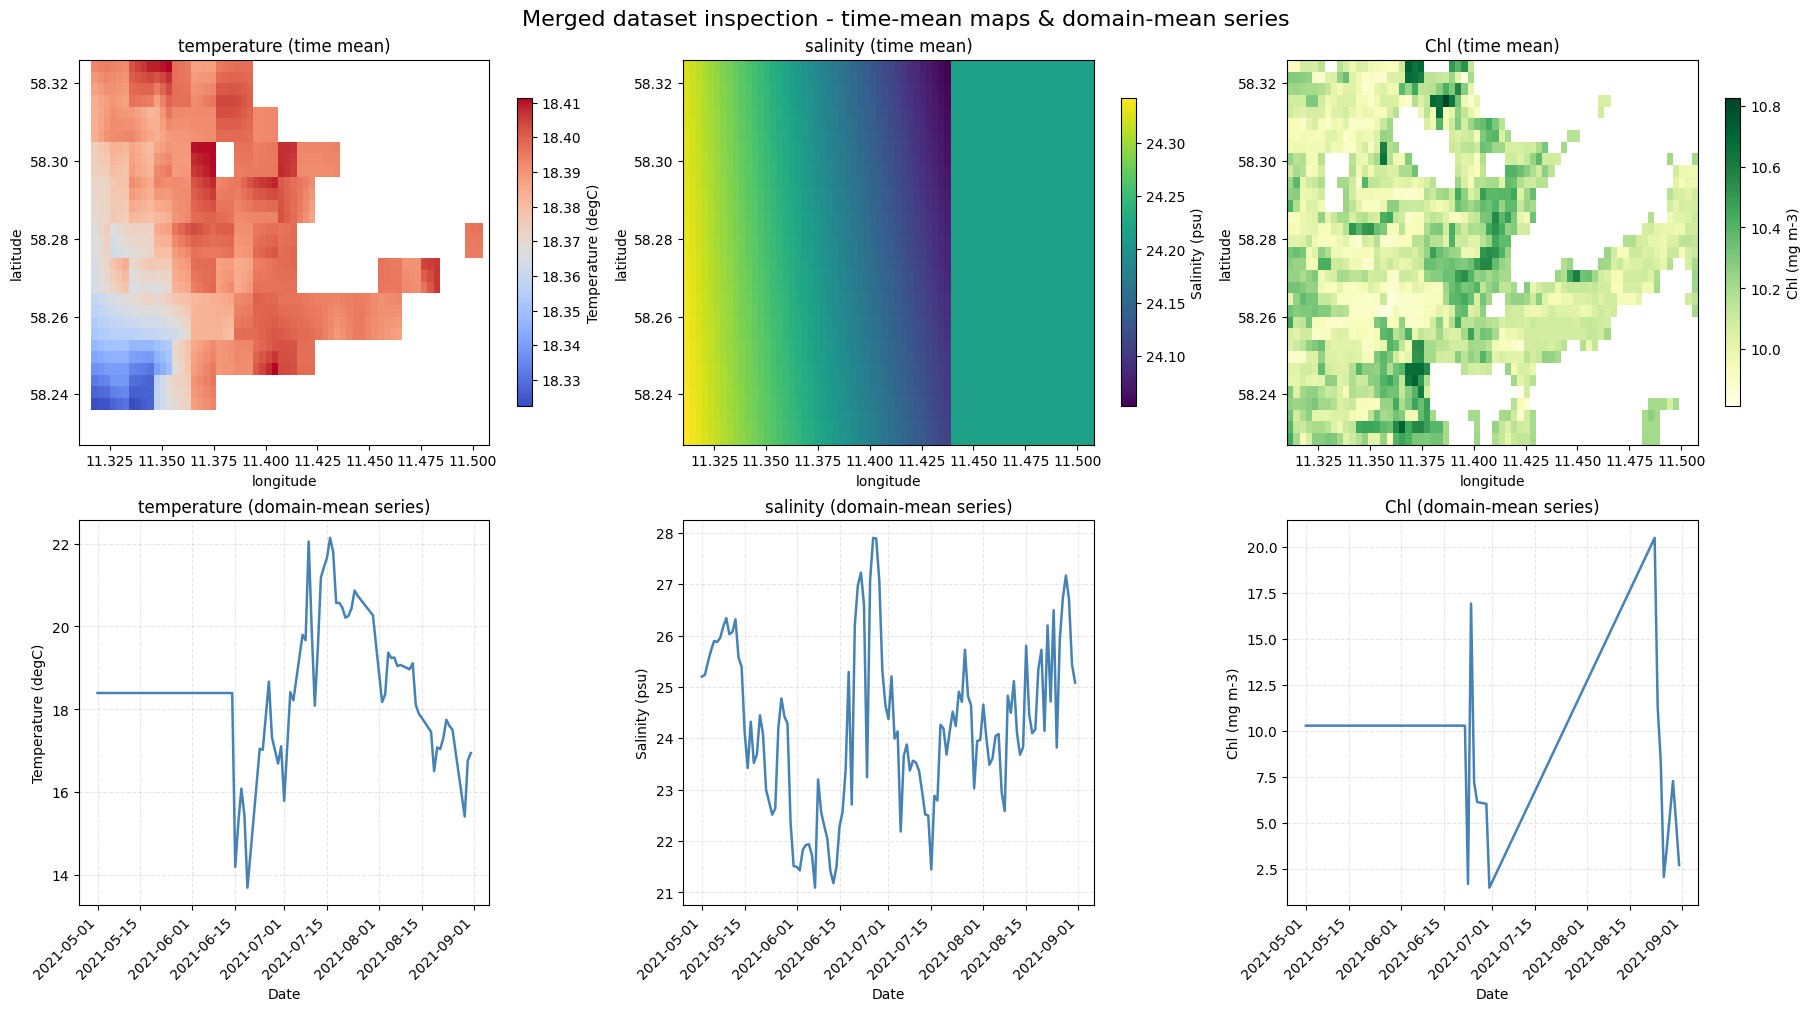

In [25]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Inspect the combined cube before running the model.
#   Top row    : spatial time-mean maps  (geographic pattern per variable)
#   Bottom row : domain-mean daily series (temporal variability per variable)
# A variable that looks flat or implausible should be checked upstream.

vars_to_plot = [
    ("temperature", "Temperature (degC)", "coolwarm"),
    ("salinity",    "Salinity (psu)",     "viridis"),
    ("Chl",         "Chl (mg m-3)",       "YlGn"),
]

if ds_daily is None or 'time' not in ds_daily.dims:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    for col, (var, label, cmap) in enumerate(vars_to_plot):
        ax_map, ax_ts = axes[0, col], axes[1, col]

        if var not in ds_daily:
            ax_map.text(0.5, 0.5, f"{var} not found", ha='center')
            ax_ts.text(0.5, 0.5, f"{var} not found", ha='center')
            continue

        da = ds_daily[var]

        # --- top: spatial time-mean map ---
        da.mean(dim='time').plot(
            ax=ax_map, cmap=cmap, add_colorbar=True,
            cbar_kwargs={'shrink': 0.8, 'label': label},
        )
        ax_map.set_title(f"{var} (time mean)")
        ax_map.set_xlabel("longitude")
        ax_map.set_ylabel("latitude")

        # --- bottom: domain-mean daily time series ---
        ts = da.mean(dim=['latitude', 'longitude'])
        ax_ts.plot(ds_daily['time'], ts, color='steelblue', lw=1.8)
        ax_ts.set_title(f"{var} (domain-mean series)")
        ax_ts.set_xlabel("Date")
        ax_ts.set_ylabel(label)
        ax_ts.grid(True, alpha=0.3, ls='--')
        for t in ax_ts.get_xticklabels():
            t.set_rotation(45)
            t.set_ha('right')

    plt.suptitle("Merged dataset inspection - time-mean maps & domain-mean series",
                 fontsize=16)
    # plt.savefig("ds_daily_inspection.png", dpi=150)
    plt.show()

Folium map built.



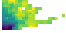
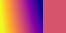
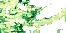

In [28]:
# Prepare variables to plot
vars_to_show = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
available_vars = [v for v in vars_to_show if v in ds_daily]

if len(available_vars) == 0:
    print("No variables available in ds_daily to create folium map.")
else:
    lat_vals = ds_daily.latitude.values
    lon_vals = ds_daily.longitude.values
    lat_min, lat_max = float(lat_vals.min()), float(lat_vals.max())
    lon_min, lon_max = float(lon_vals.min()), float(lon_vals.max())
    bounds = [[lat_min, lon_min], [lat_max, lon_max]]
    center = [(lat_min + lat_max) / 2.0, (lon_min + lon_max) / 2.0]

    # Is latitude stored ascending (south -> north)?
    lat_ascending = bool(lat_vals[0] < lat_vals[-1])

    m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

    def array_to_dataurl(arr2d, cmap_name='viridis', vmin=None, vmax=None):
        """2D array (lat x lon) -> PNG data URL.
           Folium maps image row 0 to the NORTH edge, so row 0 must be the
           northernmost latitude. We orient based on the actual lat ordering."""
        arr = np.array(arr2d, dtype=float)
        # Make row 0 == northernmost. If lats are ascending (row 0 = south),
        # flip vertically; if already descending (row 0 = north), leave as is.
        if lat_ascending:
            arr = np.flipud(arr)
        mask = np.isnan(arr)

        if vmin is None:
            vmin = np.nanpercentile(arr, 2)
        if vmax is None:
            vmax = np.nanpercentile(arr, 98)
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
            vmin, vmax = np.nanmin(arr), np.nanmax(arr)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
                vmax = vmin + 1.0

        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
        cmap = mpl.colormaps[cmap_name]          # replaces deprecated mpl.cm.get_cmap
        mapped = cmap(norm(arr))                  # RGBA float [0,1]
        mapped[..., 3][mask] = 0.0                # transparent where NaN

        rgba8 = (mapped * 255).astype(np.uint8)
        im = Image.fromarray(rgba8, mode='RGBA')
        bio = io.BytesIO()
        im.save(bio, format='PNG')
        b64 = base64.b64encode(bio.getvalue()).decode('ascii')
        return f"data:image/png;base64,{b64}"

    var_cmaps = {
        'temperature': 'viridis', 'salinity': 'plasma', 'Chl': 'YlGn',
        'POC': 'YlOrBr', 'POM': 'OrRd', 'TPM': 'inferno',
    }

    first_added = False
    for var in available_vars:
        try:
            da_mean = ds_daily[var].mean(dim='time').values
            if da_mean.ndim != 2:
                da_mean = np.squeeze(da_mean)
                if da_mean.ndim != 2:
                    print(f"Skipping {var}: not 2D after squeeze")
                    continue

            cmap = var_cmaps.get(var, 'viridis')
            vmin = np.nanpercentile(da_mean, 2)
            vmax = np.nanpercentile(da_mean, 98)
            data_url = array_to_dataurl(da_mean, cmap_name=cmap, vmin=vmin, vmax=vmax)

            folium.raster_layers.ImageOverlay(
                name=var, image=data_url, bounds=bounds,
                opacity=0.8 if not first_added else 1.0,
                interactive=True, cross_origin=False, zindex=1,
            ).add_to(m)
            first_added = True

            try:
                lc = linear.__getattribute__(cmap).scale(
                    float(np.nanmin(da_mean)), float(np.nanmax(da_mean)))
                lc.caption = f"{var} (time mean)"
                lc.add_to(m)
            except Exception:
                pass
        except Exception as e:
            print(f"Failed to add overlay for {var}: {e}")

    folium.LayerControl(collapsed=False).add_to(m)

    js = """
    <script>
    function makeOverlaysRadio(){
      var lc = document.getElementsByClassName('leaflet-control-layers')[0];
      if(!lc) { setTimeout(makeOverlaysRadio, 200); return; }
      var inputs = lc.querySelectorAll('input');
      for(var i=0; i<inputs.length; i++){
        if(inputs[i].type === 'checkbox'){
          inputs[i].type = 'radio';
          inputs[i].name = 'overlayGroup';
        }
      }
    }
    setTimeout(makeOverlaysRadio, 500);
    </script>
    """
    from folium import Element
    m.get_root().html.add_child(Element(js))
    print("Folium map built.")

try:
    display(m)
except Exception:
    pass
